In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from collections import Counter

import torch
from torch import nn, Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# NLP・形態素解析ライブラリ
import janome
from janome.tokenizer import Tokenizer
import spacy

In [49]:
df = pd.read_excel("JEC_basic_sentence_v1-3.xls", header = None)

In [122]:
len(df)

5304

In [50]:
df.iloc[:, 1].head()

0        Xではないかとつくづく疑問に思う
1           Xがいいなといつも思います
2         それがあるようにいつも思います
3          それが多すぎないかと正直思う
4    山田はみんなに好かれるタイプの人だと思う
Name: 1, dtype: str

In [78]:
j_t = Tokenizer()
def j_tokenizer(text):
    return [tok for tok in j_t.tokenize(text, wakati=True)]

# 3. 英語用のトークン変換関数を作成
e_t = spacy.load('en_core_web_sm')
def e_tokenizer(text):
    return [tok.text for tok in e_t.tokenizer(text)]

texts = df.iloc[:, 1].apply(j_tokenizer)
targets = df.iloc[:, 2].apply(e_tokenizer)

# 結果の確認
print(targets.head())

0            [I, often, wonder, if, it, might, be, X.]
1            [I, always, think, X, would, be, nice, .]
2          [It, always, seems, like, it, is, there, .]
3    [I, honestly, feel, like, there, is, too, much...
4    [I, think, that, Yamada, is, the, type, everyb...
Name: 2, dtype: object


In [79]:
SPECIAL_TOKENS = ['<unk>', '<pad>', '<bos>', '<eos>']
UNK_IDX = 0  # <unk>に割り当てるインデックス番号（0番）

def build_vocab(tokenized_texts):
    """トークン化されたテキストのリストから語彙辞書(単語 -> ID)を作成する関数"""
    counter = Counter()
    for tokens in tokenized_texts:
        counter.update(tokens)

    # 最初に特殊トークンを辞書に登録（0~3番が割り当てられる）
    word2idx = {word: idx for idx, word in enumerate(SPECIAL_TOKENS)}

    # コーパス内の単語を順番に辞書に追加
    for word, _ in counter.items():
        if word not in word2idx:
            word2idx[word] = len(word2idx) # 現在の辞書の長さを新しいIDにする

    return word2idx

# 日本語と英語のVocab（辞書）を作成
j_v = build_vocab(texts)
e_v = build_vocab(targets)


# ==========================================
# 3. 結果の確認
# ==========================================
enc_vocab_size, dec_vocab_size = len(j_v), len(e_v)

print(f"日本語の語彙サイズ: {enc_vocab_size}")
print(f"英語の語彙サイズ: {dec_vocab_size}")

# ★おまけ：未知語対策（torchtextの set_default_index の代用）
# 単語をIDに変換する際、辞書にない単語（未知語）が来たら UNK_IDX(0) を返すようにします
sample_sentence = texts[0]
sample_ids = [j_v.get(word, UNK_IDX) for word in sample_sentence]

print(f"\n最初の日本語文: {sample_sentence}")
print(f"ID化された結果: {sample_ids}")

日本語の語彙サイズ: 6446
英語の語彙サイズ: 6072

最初の日本語文: ['X', 'で', 'は', 'ない', 'か', 'と', 'つくづく', '疑問', 'に', '思う']
ID化された結果: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


In [53]:
import torch
from torch.utils.data import Dataset

# 最大単語数の設定（27にしてもOKです！）
MAX_WORD_COUNT = 32
j_word_count = 32
# 最終的な長さ（元の単語数 + <bos> + <eos> なので +2 します）
SEQ_LEN = MAX_WORD_COUNT + 2

class TranslationDataset(Dataset):
    def __init__(self, df, j_vocab, e_vocab, seq_len):
        # 1. データのトークン化
        self.texts = df.iloc[:, 1].apply(j_tokenizer).tolist()
        self.targets = df.iloc[:, 2].apply(e_tokenizer).tolist()

        # 2. 辞書と長さの設定を保存
        self.j_v = j_vocab
        self.e_v = e_vocab
        self.seq_len = seq_len

        # 特殊トークンのID（先ほど build_vocab で0~3に設定したもの）
        self.UNK_IDX = 0
        self.PAD_IDX = 1
        self.BOS_IDX = 2
        self.EOS_IDX = 3

    def transform_text(self, tokens, vocab):
        """ T.Sequential の代わりとなるテキスト変換関数 """
        # ① VocabTransform: 単語をIDに変換（辞書になければ UNK_IDX(0)）
        ids = [vocab.get(tok, self.UNK_IDX) for tok in tokens]

        # ② Truncate: 指定した長さで切り捨てる（bosとeosが入る分、-2 しておく）
        ids = ids[:self.seq_len - 2]

        # ③ AddToken: 文頭に <bos> (2)、文末に <eos> (3) を追加
        ids = [self.BOS_IDX] + ids + [self.EOS_IDX]

        # ④ PadTransform: 足りない部分を <pad> (1) で埋めて長さを統一
        pad_length = self.seq_len - len(ids)
        ids = ids + [self.PAD_IDX] * pad_length

        # ⑤ ToTensor: PyTorchのテンソルに変換
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        # 日本語文を取り出して変換
        text_tokens = self.texts[i]
        text_tensor = self.transform_text(text_tokens, self.j_v)

        # 英語文を取り出して変換
        target_tokens = self.targets[i]
        target_tensor = self.transform_text(target_tokens, self.e_v)

        # 翻訳モデル用の入力と正解（Teacher Forcing）を1つずらして作成
        dec_input = target_tensor[:-1]
        dec_target = target_tensor[1:]

        # 辞書型で返す
        return {"text": text_tensor, "dec_input": dec_input, "dec_target": dec_target}

# ==========================================
# 実際にDatasetを作って、中身を確認してみる
# ==========================================
# インスタンス化（先ほど作った j_v, e_v を渡します）
dataset = TranslationDataset(df, j_v, e_v, seq_len=SEQ_LEN)

# 最初のデータ（0番目）を取り出してみる
sample_data = dataset[0]

print("■ 日本語（エンコーダ入力）のテンソル:")
print(sample_data["text"])
print("\n■ 英語（デコーダ入力: dec_input）のテンソル:")
print(sample_data["dec_input"])
print("\n■ 英語（デコーダ正解: dec_target）のテンソル:")
print(sample_data["dec_target"])

■ 日本語（エンコーダ入力）のテンソル:
tensor([ 2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,  3,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

■ 英語（デコーダ入力: dec_input）のテンソル:
tensor([ 2,  4,  5,  6,  7,  8,  9, 10, 11,  3,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

■ 英語（デコーダ正解: dec_target）のテンソル:
tensor([ 4,  5,  6,  7,  8,  9, 10, 11,  3,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])


In [54]:
BATCH_SIZE = 32
data_loader = DataLoader(dataset,
                          batch_size=BATCH_SIZE,
                          num_workers=4,
                          drop_last=True,
                          shuffle=True)

data = next(iter(data_loader))
text, dec_input, target = data["text"], data["dec_input"], data["dec_target"]
print(text[0], dec_input[0], target[0], sep="\n")

tensor([   2,    4,   14, 6340,   33,    3,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
           1,    1,    1,    1,    1,    1,    1,    1,    1,    1])
tensor([  2,  14,  21, 218,  17,   3,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1])
tensor([ 14,  21, 218,  17,   3,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          1,   1,   1,   1,   1])


In [55]:
text.size()

torch.Size([32, 34])

ここからtransfoemerの部分

In [56]:
class PositionalEncoding(nn.Module):

  def __init__(self, dim, dropout = 0.1, max_len = 5000):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)
    position = torch.arange(max_len).unsqueeze(1).to(device)#[5000,1]
    div_term = torch.exp(torch.arange(0, dim, 2) * (-math.log(10000.0) / dim)).to(device)#計算が破綻品ようにしている
    pe = torch.zeros(1, max_len, dim).to(device)#3次元のテンソルにしている#[単語，バッチ，512]
    pe[0, :, 0::2] = torch.sin(position * div_term)
    pe[0, :, 1::2] = torch.cos(position * div_term)
    self.register_buffer('pe', pe)#モデルのパラメータではないが、保存・読み込みの対象にするための処理

  def forward(self, x):
    x = x + self.pe[:, :x.size(1), :]
    return self.dropout(x) #[バッチ、単語、512]

In [57]:
class MultiHeadAttention(nn.Module):

  def __init__(self, dim, head_num, dropout = 0.1):
    super().__init__()
    self.dim = dim
    self.head_num = head_num
    self.linear_Q = nn.Linear(dim, dim, bias = False)#重み行列　Qを作るための線形変換
    self.linear_K = nn.Linear(dim, dim, bias = False)
    self.linear_V = nn.Linear(dim, dim, bias = False)
    self.linear = nn.Linear(dim, dim, bias = False)
    self.soft = nn.Softmax(dim = 3)
    self.dropout = nn.Dropout(dropout)

  def split_head(self, x):
    x = torch.tensor_split(x, self.head_num, dim = 2)#入力[バッチサイズ, 単語数, 512]
    x = torch.stack(x, dim = 1)#[バッチサイズ, 8(ヘッド数), 単語数, 64]
    return x

  def concat_head(self, x):
    x = torch.tensor_split(x, x.size()[1], dim = 1)#[バッチ, 1, 単語数, 64]
    x = torch.concat(x, dim = 3).squeeze(dim = 1)#[バッチ, 単語数, 512]
    return x

  def forward(self, Q, K, V, mask = None):
    Q = self.linear_Q(Q)   #(BATCH_SIZE,word_count,dim)
    K = self.linear_K(K)
    V = self.linear_V(V)

    Q = self.split_head(Q) 
    K = self.split_head(K)
    V = self.split_head(V)

    QK = torch.matmul(Q, torch.transpose(K, 3, 2))
    QK = QK/((self.dim//self.head_num)**0.5)

    if mask is not None:
      QK = QK + mask

    softmax_QK = self.soft(QK)
    softmax_QK = self.dropout(softmax_QK)#[B, 8, N, N]

    QKV = torch.matmul(softmax_QK, V)#[バッチサイズ, 8, 単語数, 64]
    QKV = self.concat_head(QKV)#[バッチ, 単語数, 512]
    QKV = self.linear(QKV)
    return QKV

In [58]:
class FeedForward(nn.Module):

  def __init__(self, dim, hidden_dim = 2048, dropout = 0.1):
    super().__init__()
    self.dropout = nn.Dropout(dropout)
    self.linear_1 = nn.Linear(dim, hidden_dim)
    self.relu = nn.ReLU()
    self.linear_2 = nn.Linear(hidden_dim, dim)

  def forward(self, x):
    x = self.linear_1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.linear_2(x)
    return x


In [59]:
class EncoderBlock(nn.Module):

  def __init__(self, dim, head_num, dropout = 0.1):
    super().__init__()
    self.MHA = MultiHeadAttention(dim, head_num)
    self.layer_norm_1 = nn.LayerNorm([dim])
    self.layer_norm_2 = nn.LayerNorm([dim])
    self.FF = FeedForward(dim)
    self.dropout_1 = nn.Dropout(dropout)
    self.dropout_2 = nn.Dropout(dropout)

  def forward(self, x):
    Q = K = V = x
    x = self.MHA(Q, K, V)
    x = self.dropout_1(x)
    x = x + Q
    x = self.layer_norm_1(x)
    _x = x
    x = self.FF(x)
    x = self.dropout_2(x)
    x = x + _x
    x = self.layer_norm_2(x)
    return x

In [60]:
class Encoder(nn.Module):

  def __init__(self, enc_vocab_size, dim, head_num, dropout = 0.1):
    super().__init__() 
    self.dim = dim
    self.embed = nn.Embedding(enc_vocab_size, dim)
    self.PE = PositionalEncoding(dim)
    self.dropout = nn.Dropout(dropout)
    self.EncoderBlocks = nn.ModuleList([EncoderBlock(dim, head_num) for _ in range(6)])

  def forward(self, x):
    x = self.embed(x)
    x = x*(self.dim**0.5)
    x = self.PE(x)
    x = self.dropout(x)
    for i in range(6):
      x = self.EncoderBlocks[i](x)
    return x

デコーダ部分

In [61]:
class DecoderBlock(nn.Module):

  def __init__(self, dim, head_num, dropout = 0.1):
    super().__init__() 
    self.MMHA = MultiHeadAttention(dim, head_num)
    self.MHA = MultiHeadAttention(dim, head_num)
    self.layer_norm_1 = nn.LayerNorm([dim])
    self.layer_norm_2 = nn.LayerNorm([dim])
    self.layer_norm_3 = nn.LayerNorm([dim])
    self.FF = FeedForward(dim)
    self.dropout_1 = nn.Dropout(dropout)
    self.dropout_2 = nn.Dropout(dropout)
    self.dropout_3 = nn.Dropout(dropout)

  def forward(self, x, y, mask):
    Q = K = V = x
    x = self.MMHA(Q, K, V, mask)
    x = self.dropout_1(x)
    x = x + Q
    x = self.layer_norm_1(x)
    Q = x
    K = V = y
    x = self.MHA(Q, K, V)
    x = self.dropout_2(x)
    x = x + Q
    x = self.layer_norm_2(x)
    _x = x
    x = self.FF(x)
    x = self.dropout_3(x)
    x = x + _x
    x = self.layer_norm_3(x)
    return x

In [62]:
class Decoder(nn.Module):

  def __init__(self, dec_vocab_size, dim, head_num, dropout = 0.1):
    super().__init__() 
    self.dim = dim
    self.embed = nn.Embedding(dec_vocab_size, dim)
    self.PE = PositionalEncoding(dim)
    self.DecoderBlocks = nn.ModuleList([DecoderBlock(dim, head_num) for _ in range(6)])
    self.dropout = nn.Dropout(dropout)
    self.linear = nn.Linear(dim, dec_vocab_size)

  def forward(self, x, y, mask):
    x = self.embed(x)#[64,15]を、単語数*512の行列に変換,ｘに該当するところだけget
    x = x*(self.dim**0.5)
    x = self.PE(x)
    x = self.dropout(x)
    for i in range(6):
      x = self.DecoderBlocks[i](x, y, mask)
    x = self.linear(x)   #損失の計算にnn.CrossEntropyLoss()を使用する為、Softmax層を挿入しない
    return x

In [63]:
class Transformer(nn.Module):
  
  def __init__(self, enc_vocab_size, dec_vocab_size, dim, head_num):
    super().__init__() 
    self.encoder = Encoder(enc_vocab_size, dim, head_num)
    self.decoder = Decoder(dec_vocab_size, dim, head_num)

  def forward(self, enc_input, dec_input, mask):
    enc_output = self.encoder(enc_input)
    output = self.decoder(dec_input, enc_output, mask)
    return output

In [67]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = Transformer(enc_vocab_size, dec_vocab_size, dim = 512, head_num = 8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epoch_num = 200
print_coef = 10
train_length = len(dataset)

history = {"train_loss": []}
n = 0
train_loss = 0

for epoch in range(epoch_num):
  model.train()
  for i, data in enumerate(data_loader):
    optimizer.zero_grad()
    text, dec_input, target = data["text"].to(device), data["dec_input"].to(device), data["dec_target"].to(device)
    mask = nn.Transformer.generate_square_subsequent_mask(j_word_count + 1).to(device)   #マスクの作成

    outputs = model(text, dec_input, mask)#[32,16,辞書の数]
    outputs_flat = outputs.view(-1, dec_vocab_size)
    target_flat = target.view(-1)
    loss = criterion(outputs_flat, target_flat)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    history["train_loss"].append(loss.item())
    n += 1
    if i % ((train_length//BATCH_SIZE)//print_coef) == (train_length//BATCH_SIZE)//print_coef - 1:
      print(f"epoch:{epoch+1}  index:{i+1}  loss:{train_loss/n:.10f}")
      train_loss = 0
      n = 0

epoch:1  index:16  loss:3.0377907008
epoch:1  index:32  loss:2.1176020503
epoch:1  index:48  loss:1.8983959183
epoch:1  index:64  loss:1.8142846450
epoch:1  index:80  loss:1.8097432256
epoch:1  index:96  loss:1.7516335323
epoch:1  index:112  loss:1.7663074881
epoch:1  index:128  loss:1.7185861319
epoch:1  index:144  loss:1.6925571337
epoch:1  index:160  loss:1.6837854534
epoch:2  index:16  loss:1.5908443985
epoch:2  index:32  loss:1.6080920547
epoch:2  index:48  loss:1.5953814834
epoch:2  index:64  loss:1.6257219687
epoch:2  index:80  loss:1.6209418178
epoch:2  index:96  loss:1.5415777043
epoch:2  index:112  loss:1.5696194991
epoch:2  index:128  loss:1.5564280748
epoch:2  index:144  loss:1.5538484678
epoch:2  index:160  loss:1.5726136938
epoch:3  index:16  loss:1.5070807707
epoch:3  index:32  loss:1.4952353761
epoch:3  index:48  loss:1.4985982925
epoch:3  index:64  loss:1.4656252861
epoch:3  index:80  loss:1.4669518620
epoch:3  index:96  loss:1.4607866481
epoch:3  index:112  loss:1.478

In [68]:
torch.save(model.state_dict(), "transformer_weights.pth")

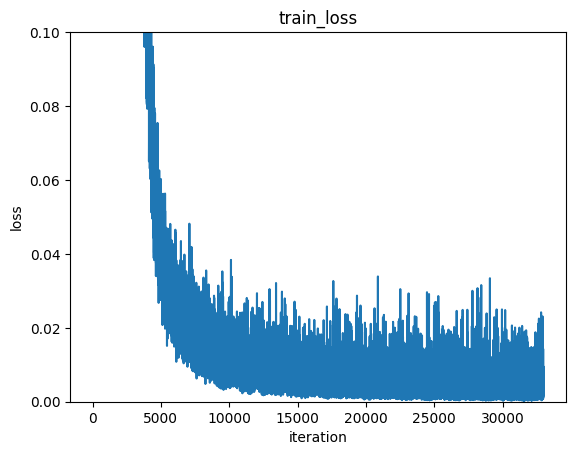

In [70]:
fig,ax =plt.subplots()
ax.plot(history["train_loss"])
ax.set_ylim(0, 0.1)
ax.set_title("train_loss")
ax.set_xlabel("iteration")
ax.set_ylabel("loss")
plt.show()

予測をしてみよう

In [80]:
def preprocess_for_encoder(text, j_vocab, tokenizer, seq_len, device):
    UNK_IDX = 0
    PAD_IDX = 1
    BOS_IDX = 2
    EOS_IDX = 3

    tokens = tokenizer(text)
    ids = [j_vocab.get(tok, UNK_IDX) for tok in tokens]

    # 3. Truncate: 指定長で切り捨てる（bosとeosが入る分、-2 しておく）
    ids = ids[:seq_len - 2]

    # 4. AddToken: 文頭に <bos> (2)、文末に <eos> (3) を追加
    ids = [BOS_IDX] + ids + [EOS_IDX]

    # 5. PadTransform: 足りない部分を <pad> (1) で埋める
    pad_length = seq_len - len(ids)
    ids = ids + [PAD_IDX] * pad_length

    # 6. ToTensor & Device: バッチ次元 [1, seq_len] を追加してGPUへ送る
    src_tensor = torch.tensor([ids], dtype=torch.long).to(device)
    
    return src_tensor

In [81]:
input_text = "私はリンゴが好きです"
src_tensor = preprocess_for_encoder(
    text=input_text, 
    j_vocab=j_v, 
    tokenizer=j_tokenizer, 
    seq_len=SEQ_LEN, 
    device=device
)

In [83]:
src_tensor.size()


torch.Size([1, 34])

In [ ]:
model.eval()
BOS_IDX = 2
EOS_IDX = 3
dec_input = torch.tensor([[BOS_IDX]]).to(device)
max_len = 50
with torch.no_grad():
    for i in range(max_len):
        
        mask = nn.Transformer.generate_square_subsequent_mask(dec_input.size(1)).to(device)
        outputs = model(src_tensor, dec_input, mask)
        next_token_logits = outputs[:, -1, :] #[1,1,辞書]
        next_token_id = next_token_logits.argmax(dim=-1).item()
        if next_token_id == EOS_IDX:
            break
            
        next_tensor = torch.tensor([[next_token_id]]).to(device)
        dec_input = torch.cat([dec_input, next_tensor], dim=1)

In [ ]:
predict_ids = dec_input.squeeze(0).tolist()[1:]

print("AIが予測した英語の単語IDリスト:")
print(predict_ids)

▼ AIが予測した英語の単語IDリスト:
[4, 452, 1690, 3282, 4531, 17]


理解不能

In [ ]:
id2word_e = {idx: word for word, idx in e_v.items()}
translated_words = [id2word_e.get(idx, "<unk>") for idx in predict_ids]
translated_sentence = " ".join(translated_words)

# 結果の表示
print("▼翻訳結果")
print(translated_sentence)

▼ 翻訳結果
I 've never touch panel .


ビームサーチしてみる
トータル確率で比較したもの

In [116]:
def beam_search_translate(model, src_tensor, beam_size=4, max_len=50):
    model.eval()
    
    BOS_IDX = 2
    EOS_IDX = 3
    
    # 候補（ビーム）を管理するリスト
    # seq: これまでの単語IDリスト, score: これまでの確率の合計スコア
    beams = [{"seq": [BOS_IDX], "score": 0.0}]
    completed_beams = []
    
    with torch.no_grad():
        for i in range(max_len):
            new_beams = []

            for beam in beams:
                # 既に <EOS> に到達している候補は、それ以上予測せずそのままキープ
                if beam["seq"][-1] == EOS_IDX:
                    completed_beams.append(beam)
                    continue
                
                dec_input = torch.tensor([beam["seq"]]).to(device)
                mask = nn.Transformer.generate_square_subsequent_mask(dec_input.size(1)).to(device)
                
                outputs = model(src_tensor, dec_input, mask)
                logits = outputs[:, -1, :]
                
                # 🎯【重要1】確率を対数（Log）に変換する
                log_probs = F.log_softmax(logits, dim=-1)
                
                # 確率が高い上位 beam_size 個の単語とそのスコアを取得
                topk_log_probs, topk_indices = log_probs.topk(beam_size, dim=-1)
                
                # 選ばれた単語を現在の候補に枝分かれさせて追加
                for k in range(beam_size):
                    next_token_id = topk_indices[0, k].item()
                    prob = topk_log_probs[0, k].item()
                    
                    new_beams.append({
                        "seq": beam["seq"] + [next_token_id],
                        "score": beam["score"] + prob # 🎯【重要2】対数なので「足し算」で確率を結合
                    })

            if not new_beams:
                break
                

            beams = sorted(new_beams, key=lambda x: x["score"], reverse=True)[:beam_size]

            if all(beam["seq"][-1] == EOS_IDX for beam in beams):
                break

    # 途中で完了した候補と、最後まで生き残った候補を合流させる
    final_beams = completed_beams + beams
    sorted_beams = sorted(final_beams, key=lambda x: x["score"], reverse=True)
    # 最もスコアが高い（= 確率が高い）文章を1つ選んで返す
    best_beam = max(final_beams, key=lambda x: x["score"])
    
    # 先頭の <BOS> を除いて返す
    return [(beam["seq"][1:], beam["score"]) for beam in sorted_beams[:10]]

In [120]:
predict_ids = beam_search_translate(
    model=model, 
    src_tensor=src_tensor, 
    beam_size=4, 
    max_len=32
)

全然だめ、参考にした人の記事でも書いてあったが、データが少ないのは間違えなく要因になる。

In [121]:
for rank, (predict_ids, score) in enumerate(predict_ids, 1):
    translated_words = []
    for idx in predict_ids:
        if idx == 3: 
            break
        translated_words.append(id2word_e.get(idx, "<unk>"))
        
    translated_text = " ".join(translated_words)
    confidence = math.exp(score)
    
    print(f"第 {rank} 位 (スコア: {score:.4f} / 確信度: {confidence:.5f})")
    print(f"{translated_text}")
    print("-" * 50)

第 1 位 (スコア: -2.8178 / 確信度: 0.05974)
I 've never dated any guys .
--------------------------------------------------
第 2 位 (スコア: -2.9854 / 確信度: 0.05052)
I 've recently .
--------------------------------------------------
第 3 位 (スコア: -3.2995 / 確信度: 0.03690)
I 've never dated any alcohol .
--------------------------------------------------
第 4 位 (スコア: -3.5581 / 確信度: 0.02849)
I 've never touch panel .
--------------------------------------------------
第 5 位 (スコア: -3.6318 / 確信度: 0.02647)
I 've never touch me .
--------------------------------------------------
第 6 位 (スコア: -19.0378 / 確信度: 0.00000)
I 've never dated any alcohol . .
--------------------------------------------------
第 7 位 (スコア: -22.8004 / 確信度: 0.00000)
I 've never dated any alcohol . Eve .
--------------------------------------------------
第 8 位 (スコア: -35.3004 / 確信度: 0.00000)
I 've never dated any alcohol . . .
--------------------------------------------------
第 9 位 (スコア: -37.3409 / 確信度: 0.00000)
I 've never dated any alcohol